<a href="https://colab.research.google.com/github/rhyan-rpone/rponeconsultoria/blob/main/Analise_Social_Media_Tempo_de_Uso_Jovens_e_Adolescentes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("algozee/teenager-menthal-healy")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'teenager-menthal-healy' dataset.
Path to dataset files: /kaggle/input/teenager-menthal-healy


In [3]:
# Importando libs - Pandas, Numpy, MatplotLib e Seaborn para análise, manipulação e visualização de dados
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
#Acessando e lendo nosso dataframe
Base_Dados = pd.read_csv('Teen_Mental_Health_Dataset.csv')

In [ ]:
# Verificando estrutura de dados com .head()
# Esse dataset está com o idioma em ingles, vamos operar com ele neste idioma.
Base_Dados.head()


,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


In [ ]:
# Verificando a dimensão dos dados com shape()
# temos 1.200 linhas e 13 colunas nesse dataset
Base_Dados.shape

(1200, 13)

In [6]:
# Verificando se temos null values
Base_Dados.isnull().sum()

## Não temos valores nulos em nenhuma das colunas do dataset

,0
age,0
gender,0
daily_social_media_hours,0
platform_usage,0
sleep_hours,0
screen_time_before_sleep,0
academic_performance,0
physical_activity,0
social_interaction_level,0
stress_level,0


In [13]:
Base_Dados.describe()

# Podmos observar os seguintes pontos:
# Temos jovens com idade entre 13 a 19 anos de idade, com uma média de 6,4 horas de sono e 4,53 de horas diárias em redes sociais .
# Destes jovens, uma média fica 1 hora e meia com o celular antes de dormir, o que resulta em uma média de 5,63 de 0 a 10 pro nível de ansiedade desses jovens e 5,56 de vício nas redes.

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,15.928333,4.536667,6.449417,1.740333,2.990383,1.014500,5.445833,5.636667,5.565000,0.025833
std,2.021947,2.029599,1.442677,0.716660,0.576758,0.582185,2.903290,2.859453,2.830627,0.158704
min,13.000000,1.000000,4.000000,0.500000,2.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,14.000000,2.800000,5.200000,1.100000,2.500000,0.500000,3.000000,3.000000,3.000000,0.000000
50%,16.000000,4.500000,6.500000,1.800000,2.990000,1.000000,5.000000,6.000000,6.000000,0.000000
75%,18.000000,6.300000,7.600000,2.400000,3.480000,1.500000,8.000000,8.000000,8.000000,0.000000
max,19.000000,8.000000,9.000000,3.000000,4.000000,2.000000,10.000000,10.000000,10.000000,1.000000


In [11]:
#Dimensao _ Qtd de linhas e colunas
Base_Dados.shape

(1200, 13)

In [10]:
# Checando Data Types da tabela
Base_Dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   object 
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   object 
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   object 
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), object(3)
memory usage: 122.0+ KB


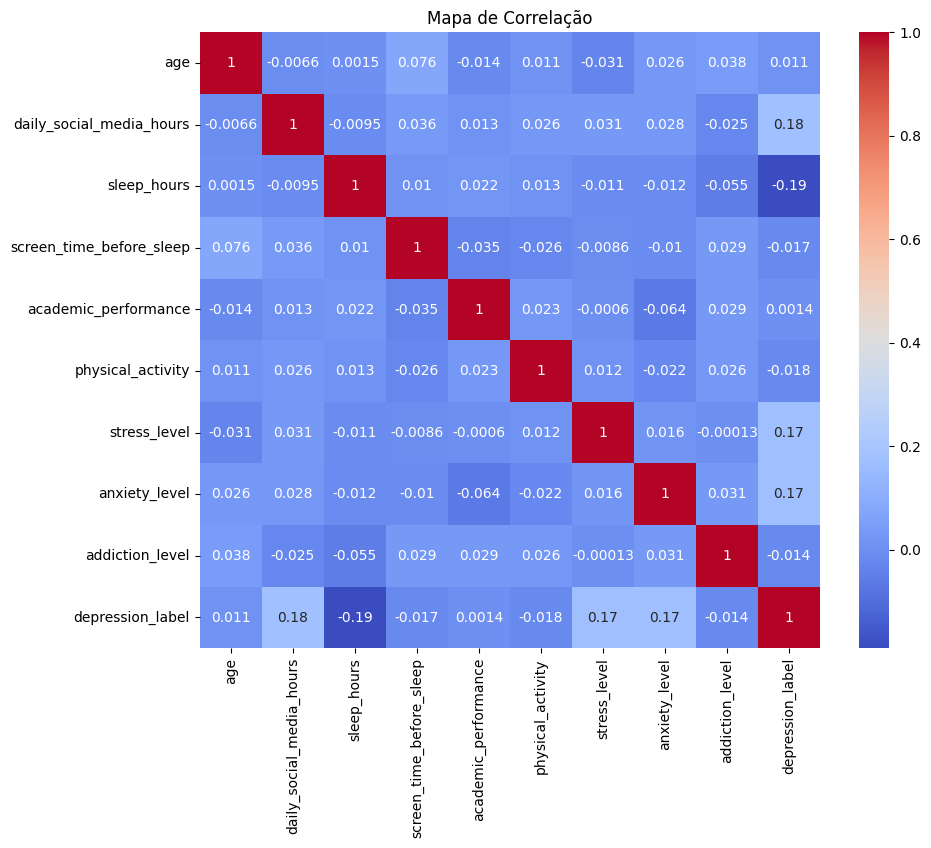

In [19]:
# Correlação geral entre variáveis

corr = Base_Dados.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Mapa de Correlação')
plt.show()

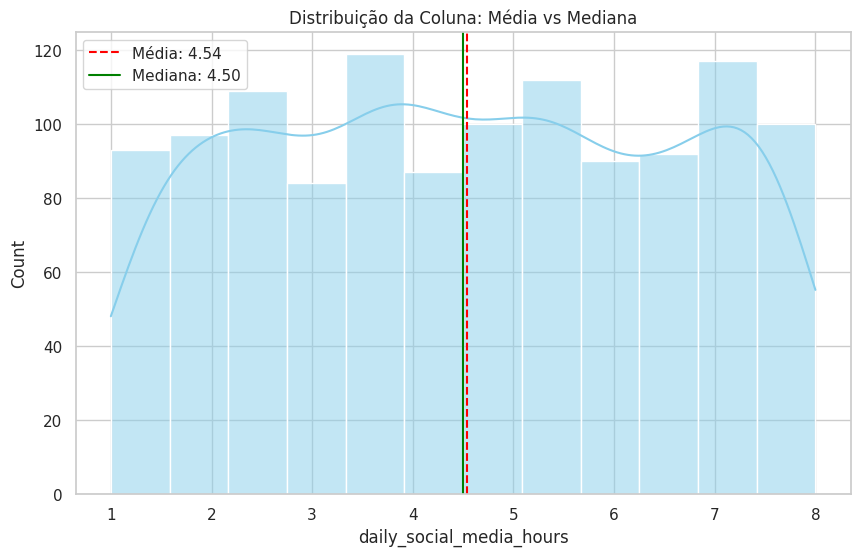

In [ ]:
# Validando média ou mediana para termos a média de horas gastas nas plataformas
# Estamos analisando a distribuição dos dados pra definir qual métrica usar
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Criando o gráfico
sns.histplot(Base_Dados['daily_social_media_hours'], kde=True, color='skyblue')

# Adicionando linhas de referência
plt.axvline(Base_Dados['daily_social_media_hours'].mean(), color='red', linestyle='--', label=f"Média: {Base_Dados['daily_social_media_hours'].mean():.2f}")
plt.axvline(Base_Dados['daily_social_media_hours'].median(), color='green', linestyle='-', label=f"Mediana: {Base_Dados['daily_social_media_hours'].median():.2f}")

plt.title('Distribuição da Coluna: Média vs Mediana')
plt.legend()
plt.show()

/tmp/ipykernel_2211/2842203616.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=Base_Dados['daily_social_media_hours'], palette="Set2")


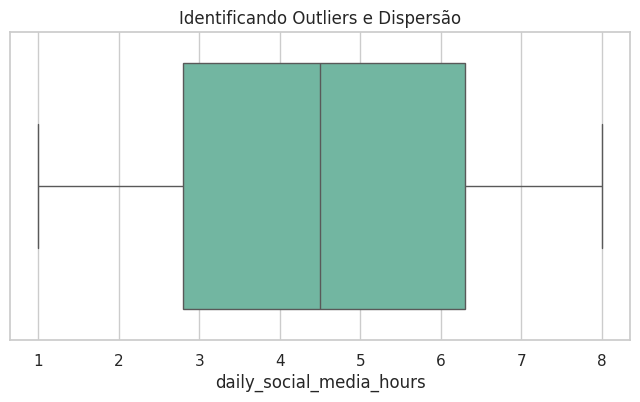

In [ ]:
# Fazendo um re-check com Boxplot pra confirmar, os dados estão perfeitamente distriuídos
plt.figure(figsize=(8, 4))
sns.boxplot(x=Base_Dados['daily_social_media_hours'], palette="Set2")
plt.title('Identificando Outliers e Dispersão')
plt.show()

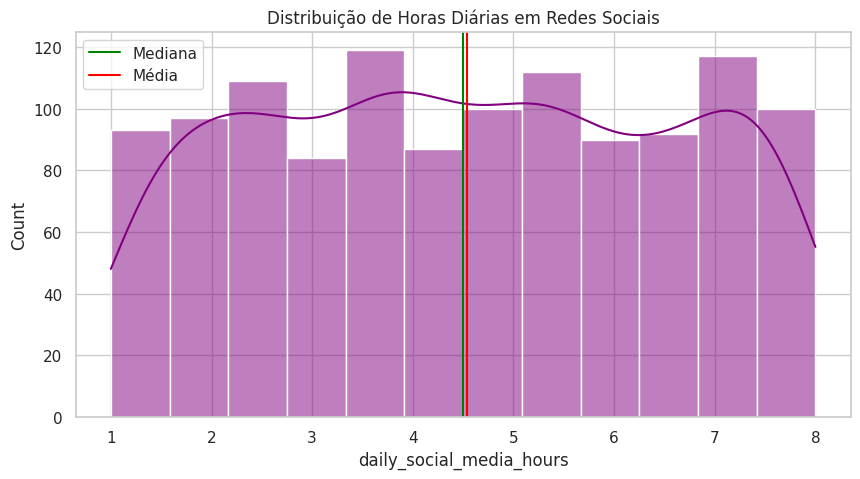

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Verificando a distribuição de horas para decidir entre Média ou Mediana
plt.figure(figsize=(10, 5))
sns.histplot(Base_Dados['daily_social_media_hours'], kde=True, color='purple')
plt.axvline(Base_Dados['daily_social_media_hours'].median(), color='green', label='Mediana')
plt.axvline(Base_Dados['daily_social_media_hours'].mean(), color='red', label='Média')
plt.title('Distribuição de Horas Diárias em Redes Sociais')
plt.legend()
plt.show()

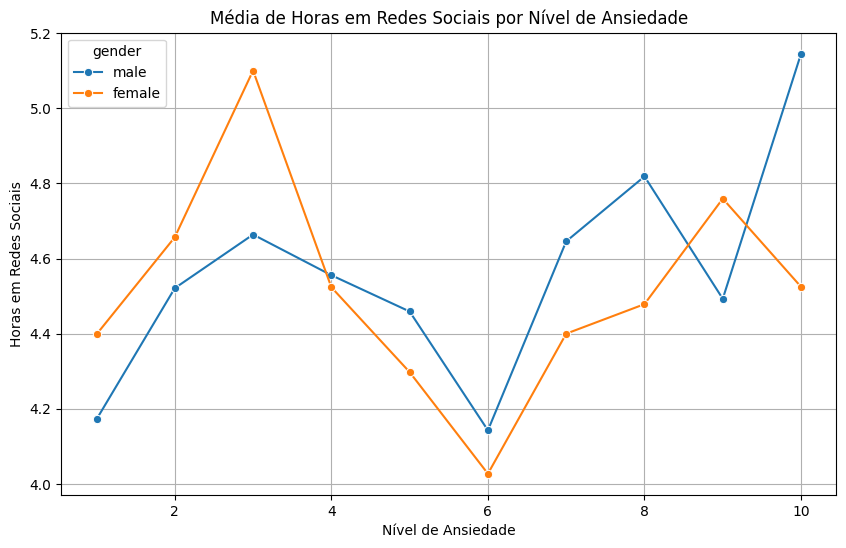

In [17]:
# Correlação de Nível de Ansiedade x Horas diárias em redes sociais x genero.
plt.figure(figsize=(10,6))

sns.lineplot(
    data=Base_Dados,
    x='anxiety_level',
    y='daily_social_media_hours',
    hue='gender',
    estimator='mean',
    errorbar=None,
    marker='o'
)

plt.title('Média de Horas em Redes Sociais por Nível de Ansiedade')
plt.xlabel('Nível de Ansiedade')
plt.ylabel('Horas em Redes Sociais')
plt.grid(True)
plt.show()


# Tanto homens quanto mulheres ficam, em média, entre 4 e 5 horas diárias em redes sociais.
# Existe uma tendência de níveis mais altos de ansiedade estarem associados a mais horas de uso, principalmente:
# homens nos níveis 7–10
# mulheres no nível 9
# Pessoas com maiores níveis de ansiedade tendem a passar mais tempo em redes sociais, porém a relação não é totalmente linear e varia entre os gêneros.

In [18]:
# Correlação de Pearson - Ansiedade x Horas diarias
from scipy.stats import pearsonr

corr, p = pearsonr(
    Base_Dados['daily_social_media_hours'],
    Base_Dados['anxiety_level']
)

print(f'Correlação de Pearson: {corr:.2f}')
print(f'P-valor: {p:.4f}')

Correlação de Pearson: 0.03
P-valor: 0.3353


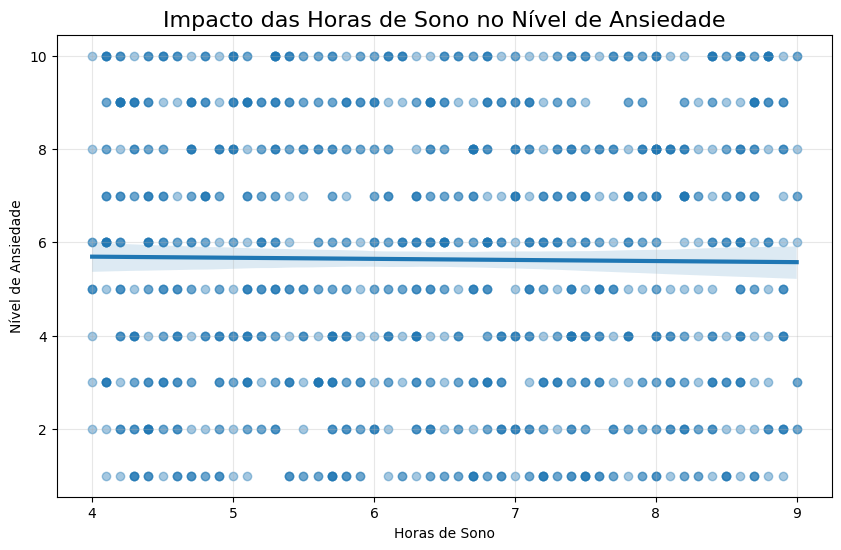

In [22]:
# Impacto do sono na ansiedade - Correlação

plt.figure(figsize=(10,6))

sns.regplot(
    data=Base_Dados,
    x='sleep_hours',
    y='anxiety_level',
    scatter_kws={'alpha':0.4},
    line_kws={'linewidth':3}
)

plt.title('Impacto das Horas de Sono no Nível de Ansiedade', fontsize=16)
plt.xlabel('Horas de Sono')
plt.ylabel('Nível de Ansiedade')

plt.grid(True, alpha=0.3)
plt.show()

# Os dados sugerem uma leve tendência de redução da ansiedade em indivíduos com maior duração de sono, porém a relação observada é fraca devido à alta dispersão dos dados.”

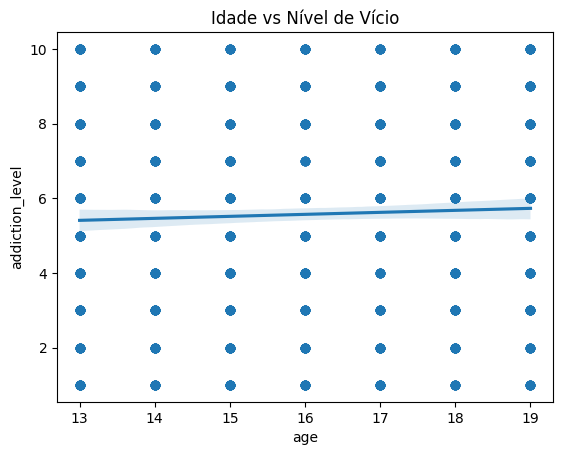

In [23]:
# Idade vs vício em redes sociais  - Correlação
sns.regplot(
    data=Base_Dados,
    x='age',
    y='addiction_level'
)

plt.title('Idade vs Nível de Vício')
plt.show()

# Os dados indicam uma relação muito fraca entre idade e nível de vício em redes sociais. O comportamento de dependência digital apresentou alta variabilidade
# em todas as faixas etárias analisadas, sugerindo que outros fatores possuem maior influência sobre o nível de vício.

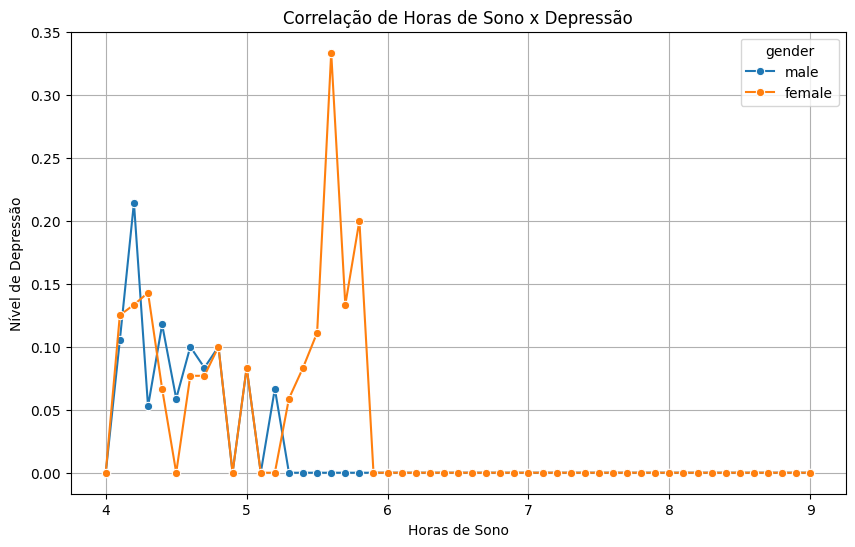

In [29]:
# Correlação entre Horas de Sono x Depressão por gênero

plt.figure(figsize=(10,6))

sns.lineplot(
    data=Base_Dados,
    x='sleep_hours',
    y='depression_label',
    hue='gender',
    errorbar=None,
    marker='o'
)

plt.title('Correlação de Horas de Sono x Depressão')
plt.xlabel('Horas de Sono')
plt.ylabel('Nível de Depressão')
plt.grid(True)

plt.show()


# Privação de sono pode impactar emocionalmente mais o grupo feminino no dataset
# ou existe maior sensibilidade psicológica associada ao sono

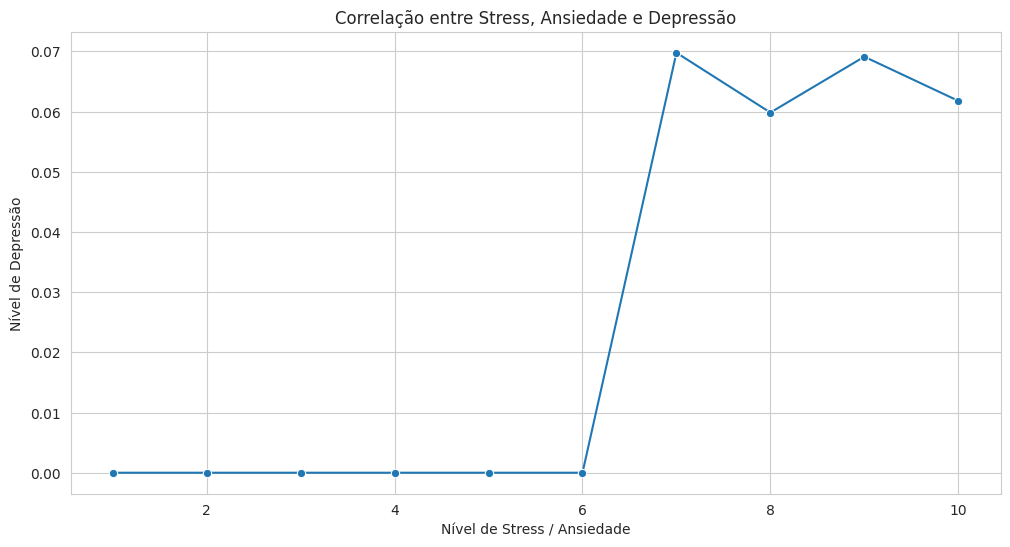

In [34]:
# Correlação entre Stress, Ansiedade x Depressão por gênero

plt.figure(figsize=(12,6))

# Transformando os dados
dados_melt = Base_Dados.melt(
    id_vars=['gender', 'depression_label'],
    value_vars=['stress_level', 'anxiety_level'],
    var_name='Variavel',
    value_name='Nivel'
)

# Gráfico
sns.lineplot(
    data=dados_melt,
    x='Nivel',
    y='depression_label',
    errorbar=None,
    marker='o'
)

plt.title('Correlação entre Stress, Ansiedade e Depressão')
plt.xlabel('Nível de Stress / Ansiedade')
plt.ylabel('Nível de Depressão')

plt.grid(True)

plt.show()

# Podemos concluir que quanto maior o stress e ansiedade, maior o nível de depressão
# Sendo assim, dormir bem, evitar o stress e ansiedade são essenciais pra manter a saúde mental intacta